# COMP90086 Final Project

In [8]:
pip install -r requirements.txt

     |████████████████████████████████| 73.6 MB 11.1 MB/s eta 0:00:01
     |████████████████████████████████| 1.9 MB 8.1 MB/s eta 0:00:01
     |████████████████████████████████| 199 kB 11.7 MB/s eta 0:00:01
  Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Using cached networkx-3.2.1-py3-none-any.whl (1.6 MB)
  Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
You should consider upgrading via the '/Users/yuluo/Desktop/UNIMELB/COMP90086/comp90086_env/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

If running on Colab

In [ ]:

# --- 1. Mount Google Drive ---
# This must be done first to access your files.
from google.colab import drive
drive.mount('/content/drive')

In [13]:

# ============================================================================
# CONFIGURATION - Update this to your data location
# ============================================================================
DATA_DIR = "./Nutrition5K"  # Change this to your actual path


In [17]:
# ============================================================================
# STEP 1: Load CSV and inspect structure
# ============================================================================
print("\n" + "="*80)
print("STEP 1: Loading CSV file")
print("="*80)

csv_path = os.path.join(DATA_DIR, "nutrition5k_train.csv")

# Check if file exists
if not os.path.exists(csv_path):
    print(f"❌ ERROR: CSV file not found at: {csv_path}")
else:
    print(f"✓ Found CSV file: {csv_path}")


# Load the CSV
df = pd.read_csv(csv_path)

print(f"\n📊 CSV Structure:")
print(f"  - Total rows: {len(df)}")
print(f"  - Columns: {list(df.columns)}")
print(f"  - Column types: {dict(df.dtypes)}")

print(f"\n📋 First 5 rows:")
print(df.head())

# Locate the column names for dish id and calorie
id_col = df.columns[0]
calorie_col = df.columns[1]
# Show some statistics
print(f"\n📈 Quick Statistics:")
print(f"  - Number of unique dishes: {df[id_col].nunique()}")
print(f"  - Calorie range: {df[calorie_col].min():.2f} - {df[calorie_col].max():.2f}")
print(f"  - Mean calories: {df[calorie_col].mean():.2f}")
print(f"  - Median calories: {df[calorie_col].median():.2f}")


STEP 1: Loading CSV file
✓ Found CSV file: ./Nutrition5K/nutrition5k_train.csv

📊 CSV Structure:
  - Total rows: 3301
  - Columns: ['ID', 'Value']
  - Column types: {'ID': dtype('O'), 'Value': dtype('float64')}

📋 First 5 rows:
          ID       Value
0  dish_0000  221.167068
1  dish_0001  140.980011
2  dish_0002  274.335999
3  dish_0003  589.501648
4  dish_0004  258.599670

📈 Quick Statistics:
  - Number of unique dishes: 3301
  - Calorie range: 0.00 - 3943.33
  - Mean calories: 237.37
  - Median calories: 186.96


DATASET LOADING - STEP BY STEP

STEP 1: Loading CSV file
✓ Found CSV file: ./Nutrition5K/nutrition5k_train.csv

📊 CSV Structure:
  - Total rows: 3301
  - Columns: ['ID', 'Value']
  - Column types: {'ID': dtype('O'), 'Value': dtype('float64')}

📋 First 5 rows:
          ID       Value
0  dish_0000  221.167068
1  dish_0001  140.980011
2  dish_0002  274.335999
3  dish_0003  589.501648
4  dish_0004  258.599670

📋 Last 5 rows:
             ID       Value
3296  dish_3296    5.250000
3297  dish_3297   89.854630
3298  dish_3298  213.670166
3299  dish_3299  268.804840
3300  dish_3300   16.020000

🔍 Auto-detecting column names...
  ✓ ID column: 'ID'
  ✓ Calorie column: 'Value'

📈 Quick Statistics:
  - Number of unique dishes: 3301
  - Calorie range: 0.00 - 3943.33
  - Mean calories: 237.37
  - Median calories: 186.96

STEP 2: Checking directory structure
✓ Found train directory: ./Nutrition5K/train
  ✓ color: ./Nutrition5K/train/color
      → 3301 dish folders found
  ✓ depth_raw: ./Nutrition5K/

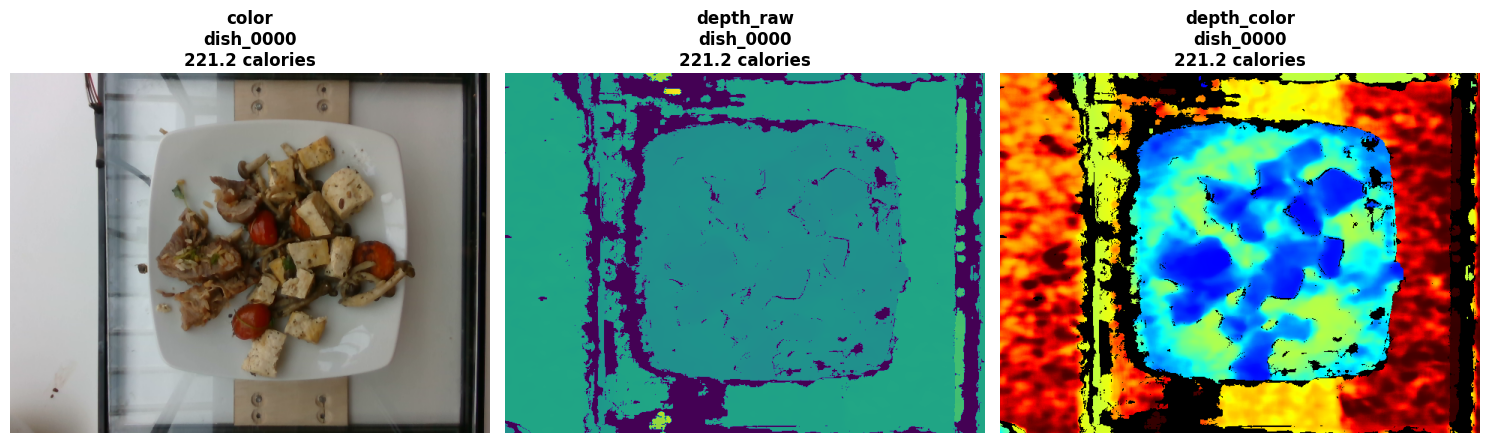


✅ Successfully loaded and displayed images!

STEP 6: Creating data loader function

Testing data loader function...
✓ Successfully loaded image for dish_0000
  Size: (640, 480)

SUMMARY

✅ Dataset successfully loaded!

📊 Dataset Info:
  - Training samples: 3301
  - ID column: 'ID'
  - Calorie column: 'Value'
  - Calorie range: 0.0 - 3943.3

📁 Available data:
  - color: ✓ Available
  - depth_raw: ✓ Available
  - depth_color: ✓ Available

🎯 Next Steps:
  1. ✓ Dataset loaded successfully
  2. → Run full Phase 1 analysis (data_exploration.py)
  3. → Run image analysis (image_analysis.py)
  4. → Start building baseline models

💡 You can now use this structure:
  df = pd.read_csv('./Nutrition5K/nutrition5k_train.csv')
  img = load_dish_data('dish_0001', 'color')

✓ DATASET LOADING COMPLETE!


In [ ]:
# ============================================================================
# STEP 2: Check directory structure
# ============================================================================
print("\n" + "="*80)
print("STEP 2: Checking directory structure")
print("="*80)

train_dir = os.path.join(DATA_DIR, "train")

if not os.path.exists(train_dir):
    print(f"❌ ERROR: Train directory not found at: {train_dir}")
    print(f"\nExpected structure:")
    print(f"  {DATA_DIR}/")
    print(f"  ├── nutrition5k_train.csv")
    print(f"  └── train/")
    print(f"      ├── color/")
    print(f"      ├── depth_raw/")
    print(f"      └── depth_color/")
    exit(1)

print(f"✓ Found train directory: {train_dir}")

# Check subdirectories
subdirs = ['color', 'depth_raw', 'depth_color']
found_subdirs = {}

for subdir in subdirs:
    subdir_path = os.path.join(train_dir, subdir)
    exists = os.path.exists(subdir_path)
    found_subdirs[subdir] = exists
    status = "✓" if exists else "❌"
    print(f"  {status} {subdir}: {subdir_path}")
    
    if exists:
        # Count dish folders
        dish_folders = [d for d in os.listdir(subdir_path) 
                       if os.path.isdir(os.path.join(subdir_path, d))]
        print(f"      → {len(dish_folders)} dish folders found")

# ============================================================================
# STEP 3: Inspect a sample dish
# ============================================================================
print("\n" + "="*80)
print("STEP 3: Inspecting sample dishes")
print("="*80)

# Get first few dish IDs from CSV
sample_dishes = df[id_col].head(5).tolist()
print(f"\nFirst 5 dish IDs from CSV: {sample_dishes}")

# Try to find these dishes in the directories
print(f"\nLooking for these dishes in image directories...")

dish_found = False
sample_dish_id = None
sample_paths = {}

for dish_id in sample_dishes:
    # Check if this dish exists in color directory
    if found_subdirs['color']:
        color_dir = os.path.join(train_dir, 'color')
        dish_dir = os.path.join(color_dir, dish_id)
        
        if os.path.exists(dish_dir):
            dish_found = True
            sample_dish_id = dish_id
            print(f"\n✓ Found dish: {dish_id}")
            
            # Check all three image types
            for img_type in subdirs:
                if found_subdirs[img_type]:
                    type_dir = os.path.join(train_dir, img_type, dish_id)
                    if os.path.exists(type_dir):
                        files = [f for f in os.listdir(type_dir) if f.endswith('.png')]
                        if files:
                            sample_paths[img_type] = os.path.join(type_dir, files[0])
                            print(f"  ✓ {img_type}: {files[0]}")
                        else:
                            print(f"  ❌ {img_type}: No PNG files found")
                    else:
                        print(f"  ❌ {img_type}: Directory doesn't exist")
            break
        else:
            print(f"  ❌ {dish_id}: Not found in color directory")

if not dish_found:
    print(f"\n❌ ERROR: Could not find any sample dishes!")
    print(f"\nPossible issues:")
    print(f"  1. Dish IDs in CSV don't match folder names")
    print(f"  2. Image folders are empty")
    print(f"  3. Directory structure is different than expected")
    exit(1)

# ============================================================================
# STEP 4: Load and display sample images
# ============================================================================
print("\n" + "="*80)
print("STEP 4: Loading sample images")
print("="*80)

images_loaded = {}

for img_type, img_path in sample_paths.items():
    try:
        img = Image.open(img_path)
        images_loaded[img_type] = img
        
        print(f"\n✓ Loaded {img_type} image:")
        print(f"  - Path: {img_path}")
        print(f"  - Size: {img.size} (width x height)")
        print(f"  - Mode: {img.mode}")
        print(f"  - Format: {img.format}")
        
        # Convert to array and show some stats
        img_array = np.array(img)
        print(f"  - Array shape: {img_array.shape}")
        print(f"  - Data type: {img_array.dtype}")
        print(f"  - Value range: {img_array.min()} - {img_array.max()}")
        
    except Exception as e:
        print(f"❌ Error loading {img_type}: {e}")

# ============================================================================
# STEP 5: Visualize the loaded images
# ============================================================================
if images_loaded:
    print("\n" + "="*80)
    print("STEP 5: Visualizing sample images")
    print("="*80)
    
    # Get calorie value for this dish
    calorie_value = df[df[id_col] == sample_dish_id][calorie_col].values[0]
    
    # Create figure
    num_images = len(images_loaded)
    fig, axes = plt.subplots(1, num_images, figsize=(5*num_images, 5))
    
    if num_images == 1:
        axes = [axes]
    
    for idx, (img_type, img) in enumerate(images_loaded.items()):
        axes[idx].imshow(img)
        axes[idx].set_title(f'{img_type}\n{sample_dish_id}\n{calorie_value:.1f} calories', 
                           fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_dish_loaded.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved visualization: sample_dish_loaded.png")
    plt.show()
    
    print(f"\n✅ Successfully loaded and displayed images!")

# ============================================================================
# STEP 6: Create a simple data loader function
# ============================================================================
print("\n" + "="*80)
print("STEP 6: Creating data loader function")
print("="*80)

def load_dish_data(dish_id, img_type='color'):
    """
    Load image for a specific dish
    
    Args:
        dish_id: Dish identifier (e.g., 'dish_0001')
        img_type: Type of image ('color', 'depth_raw', or 'depth_color')
    
    Returns:
        PIL Image object or None if not found
    """
    img_dir = os.path.join(DATA_DIR, 'train', img_type, dish_id)
    
    if not os.path.exists(img_dir):
        return None
    
    # Find PNG file
    png_files = [f for f in os.listdir(img_dir) if f.endswith('.png')]
    
    if not png_files:
        return None
    
    img_path = os.path.join(img_dir, png_files[0])
    
    try:
        return Image.open(img_path)
    except Exception as e:
        print(f"Error loading {dish_id}: {e}")
        return None

# Test the function
print(f"\nTesting data loader function...")
test_dish_id = df[id_col].iloc[0]
test_img = load_dish_data(test_dish_id, 'color')

if test_img:
    print(f"✓ Successfully loaded image for {test_dish_id}")
    print(f"  Size: {test_img.size}")
else:
    print(f"❌ Could not load image for {test_dish_id}")

# ============================================================================
# STEP 7: Summary and next steps
# ============================================================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"\n✅ Dataset successfully loaded!")
print(f"\n📊 Dataset Info:")
print(f"  - Training samples: {len(df)}")
print(f"  - ID column: '{id_col}'")
print(f"  - Calorie column: '{calorie_col}'")
print(f"  - Calorie range: {df[calorie_col].min():.1f} - {df[calorie_col].max():.1f}")

print(f"\n📁 Available data:")
for subdir, exists in found_subdirs.items():
    status = "✓ Available" if exists else "❌ Not found"
    print(f"  - {subdir}: {status}")

print(f"\n🎯 Next Steps:")
print(f"  1. ✓ Dataset loaded successfully")
print(f"  2. → Run full Phase 1 analysis (data_exploration.py)")
print(f"  3. → Run image analysis (image_analysis.py)")
print(f"  4. → Start building baseline models")

print(f"\n💡 You can now use this structure:")
print(f"  df = pd.read_csv('{csv_path}')")
print(f"  img = load_dish_data('dish_0001', 'color')")

print("\n" + "="*80)
print("✓ DATASET LOADING COMPLETE!")
print("="*80)